---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

---

## Instalação das dependências

| Biblioteca | Uso |
|------------|-----|
| `numpy` | Geração e manipulação dos datasets |
| `matplotlib` | Visualizações |
| `scikit-learn` | Normalização (`StandardScaler`) e métricas |
| `torch` | Tensores, GRU e otimizadores |

In [1]:
# %pip install numpy matplotlib scikit-learn torch --quiet

## Aula 06: Gated Recurrent Unit (GRU)

A LSTM resolve o problema do gradiente que desvanece com três gates e dois vetores de estado ($h_t$ e $c_t$). Mas essa sofisticação tem um custo: **mais parâmetros, mais memória, treinamento mais lento**.

A **GRU** (Gated Recurrent Unit), proposta por Cho et al. (2014), simplifica a LSTM:

- **Dois gates** em vez de três (reset e update)
- **Um único vetor de estado** $h_t$ — sem $c_t$
- **Menos parâmetros** → treinamento mais rápido e mais eficiente em datasets menores

Na prática, GRU e LSTM têm desempenho comparável na maioria das tarefas. A GRU costuma se sair melhor em datasets menores; a LSTM pode ter vantagem em sequências muito longas com dependências complexas.

> **Nesta aula** usaremos os **mesmos datasets da Aula 05** (Jena Climate e UCI HAR) para comparar diretamente GRU e LSTM e quantificar as diferenças.

---

## 1. Limitações da LSTM e Motivação para a GRU

A LSTM usa três gates e dois vetores de estado:

| Componente | Descrição |
|---|---|
| Forget gate $f_t$ | Decide o que esquecer do estado de célula |
| Input gate $i_t$ | Decide o que adicionar ao estado de célula |
| Output gate $o_t$ | Decide o que expor como $h_t$ |
| Cell state $c_t$ | Memória de longo prazo |
| Hidden state $h_t$ | Saída do passo atual |

Isso resulta em **4 matrizes de peso** por camada. Para um modelo com `input_size=I` e `hidden_size=H`, o número de parâmetros de uma camada LSTM é:

$$4 \times (I \cdot H + H^2 + H)$$

A GRU reduz para **3 matrizes de peso** eliminando o output gate e fundindo forget e input em um único update gate:

$$3 \times (I \cdot H + H^2 + H)$$

**Redução de ~25% nos parâmetros** com desempenho geralmente equivalente.

---

## 2. Arquitetura GRU

A GRU mantém apenas o **estado oculto** $h_t$ (sem estado de célula):

### Reset Gate

Controla quanto do estado anterior $h_{t-1}$ é esquecido ao calcular a candidata:

$$r_t = \sigma(W_r \cdot [h_{t-1},\, x_t] + b_r)$$

### Update Gate

Decide quanto do estado anterior manter vs. quanto do candidato absorver — equivale ao forget e input gate da LSTM combinados:

$$z_t = \sigma(W_z \cdot [h_{t-1},\, x_t] + b_z)$$

### Candidata ao Estado Oculto

Novo conteúdo gerado com base na entrada atual e no estado anterior filtrado pelo reset gate:

$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1},\, x_t] + b)$$

### Estado Oculto Final

Interpolação entre o estado anterior e a candidata, controlada pelo update gate:

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

> Quando $z_t \approx 0$, o estado anterior é mantido integralmente (comportamento de skip).  
> Quando $z_t \approx 1$, o estado é completamente substituído pela candidata.

### Comparativo LSTM × GRU

| Aspecto | LSTM | GRU |
|---------|------|-----|
| Gates | 3 (forget, input, output) | 2 (reset, update) |
| Vetores de estado | $h_t$ e $c_t$ | Apenas $h_t$ |
| Parâmetros | $4(IH + H^2 + H)$ | $3(IH + H^2 + H)$ |
| PyTorch | `nn.LSTM` → retorna `(out, (h_n, c_n))` | `nn.GRU` → retorna `(out, h_n)` |
| Convergência | Mais lenta | Mais rápida |
| Datasets pequenos | Pode overfitar | Generaliza melhor |

---

## 3. Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}  |  PyTorch {torch.__version__}")

Dispositivo: cpu  |  PyTorch 2.11.0


---

## 4. Caso 1 — Previsão de Temperatura (Regressão)

**Dataset:** [Jena Climate 2009–2016](https://www.kaggle.com/datasets/mnassrib/jena-climate) — estação meteorológica do Instituto Max Planck, Jena, Alemanha. Leituras a cada 10 minutos, reamostradas para **1 hora**.

**Objetivo:** prever a **temperatura do ar** `T (degC)` a partir de uma janela de `SEQ_LEN` horas de 8 variáveis meteorológicas — **idêntico ao Caso 1 da Aula 05**, permitindo comparação direta GRU × LSTM.

| Feature | Descrição |
|---|---|
| `p (mbar)` | Pressão atmosférica |
| `Tdew (degC)` | Ponto de orvalho |
| `rh (%)` | Umidade relativa |
| `VPmax (mbar)` | Pressão de vapor saturado |
| `VPact (mbar)` | Pressão de vapor atual |
| `sh (g/kg)` | Umidade específica |
| `wv (m/s)` | Velocidade do vento |
| `wd (deg)` | Direção do vento |

### 4.1 Carregamento e Pré-processamento

In [3]:
FEATURES = ["p (mbar)", "Tdew (degC)", "rh (%)", "VPmax (mbar)",
            "VPact (mbar)", "sh (g/kg)", "wv (m/s)", "wd (deg)"]
TARGET   = "T (degC)"

# ── Carrega e reamostra para frequência horária (a cada 6 linhas) ─────────
df = pd.read_csv("data/jena_climate_2009_2016.csv")
df = df.iloc[::6].reset_index(drop=True)

# Remove leituras inválidas de velocidade do vento
df["wv (m/s)"] = df["wv (m/s)"].replace(-9999.0, np.nan)
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

print(f"Amostras após reamostragem e limpeza: {len(df):,}")
print(df[FEATURES + [TARGET]].describe().round(2))

Amostras após reamostragem e limpeza: 70,089
       p (mbar)  Tdew (degC)    rh (%)  VPmax (mbar)  VPact (mbar)  sh (g/kg)  \
count  70089.00     70089.00  70089.00      70089.00      70089.00   70089.00   
mean     989.21         4.95     76.01         13.58          9.53       6.02   
std        8.36         6.73     16.48          7.74          4.18       2.66   
min      914.10       -25.01     14.20          0.95          0.79       0.50   
25%      984.20         0.23     65.21          7.78          6.21       3.92   
50%      989.58         5.22     79.30         11.82          8.86       5.59   
75%      994.72        10.06     89.40         17.60         12.35       7.80   
max     1015.28        23.11    100.00         63.26         28.32      18.13   

       wv (m/s)  wd (deg)  T (degC)  
count  70089.00  70089.00  70089.00  
mean       2.13    175.02      9.45  
std        1.54     86.80      8.42  
min        0.00      0.00    -23.01  
25%        0.99    125.90      3.36

### 4.2 Preparação: Janela Deslizante

Mesma estratégia da Aula 05: transformamos a série em pares $(X, y)$ com uma janela deslizante de tamanho $T$:

$$X_i = [s_i,\, s_{i+1},\, \ldots,\, s_{i+T-1}], \quad y_i = s_{i+T}$$

In [4]:
SEQ_LEN = 24   # 24 horas de histórico → prediz a próxima hora

scaler_X = StandardScaler().fit(df[FEATURES].values)
scaler_y = StandardScaler().fit(df[[TARGET]].values)

feat_norm = scaler_X.transform(df[FEATURES].values)
targ_norm = scaler_y.transform(df[[TARGET]].values).ravel()

X_all = np.array([feat_norm[i : i + SEQ_LEN] for i in range(len(feat_norm) - SEQ_LEN)])
y_all = targ_norm[SEQ_LEN:]

# Split 70 / 15 / 15
n = len(X_all)
n_tr, n_va = int(n * 0.70), int(n * 0.15)
X_tr, y_tr = X_all[:n_tr],       y_all[:n_tr]
X_va, y_va = X_all[n_tr:n_tr+n_va], y_all[n_tr:n_tr+n_va]
X_te, y_te = X_all[n_tr+n_va:],  y_all[n_tr+n_va:]

def to_tensor(x, dtype=torch.float32):
    return torch.tensor(x, dtype=dtype).to(device)

X_tr_t = to_tensor(X_tr);  y_tr_t = to_tensor(y_tr).unsqueeze(1)
X_va_t = to_tensor(X_va);  y_va_t = to_tensor(y_va).unsqueeze(1)
X_te_t = to_tensor(X_te);  y_te_t = to_tensor(y_te).unsqueeze(1)

BATCH = 128
loader_tr = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH, shuffle=True)

print(f"Treino  : {X_tr.shape}  |  Validação: {X_va.shape}  |  Teste: {X_te.shape}")

Treino  : (49045, 24, 8)  |  Validação: (10509, 24, 8)  |  Teste: (10511, 24, 8)


### 4.3 Modelo GRU

A única diferença em relação ao modelo LSTM da Aula 05 é substituir `nn.LSTM` por `nn.GRU`. Como a GRU não possui estado de célula, o retorno é simplesmente `(output, h_n)` — sem tupla no estado.

```
Entrada  : (batch, 24, 8)
GRU      : hidden=64, layers=2, dropout=0.2
Saída h_T: (batch, 64)   ← último estado oculto
FC       : Linear(64 → 1)
Loss     : MSELoss
```

In [5]:
class PrevisaoGRU(nn.Module):
    """
    GRU many-to-one — Previsão de temperatura.

    Entrada : (batch, seq_len, 8)  → 8 variáveis meteorológicas por hora
    Saída   : (batch, 1)           → T (degC) na próxima hora
    """
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # h_n: (num_layers, batch, hidden_size)
        _, h_n = self.gru(x)
        return self.fc(h_n[-1])   # último estado oculto da camada final

modelo_reg = PrevisaoGRU().to(device)

total_params = sum(p.numel() for p in modelo_reg.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {total_params:,}")
print(modelo_reg)

Parâmetros treináveis: 39,233
PrevisaoGRU(
  (gru): GRU(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### 4.4 Treinamento

| Hiperparâmetro | Valor |
|----------------|-------|
| Épocas         | 50    |
| Learning rate  | 1e-3  |
| Batch size     | 128   |
| Otimizador     | Adam  |
| Perda          | MSELoss |
| Gradient clip  | 1.0   |
| Early stopping | 10 épocas sem melhora |

In [6]:
EPOCHS   = 50
LR       = 1e-3
PATIENCE = 10

criterio   = nn.MSELoss()
otimizador = optim.Adam(modelo_reg.parameters(), lr=LR)

hist_tr, hist_va   = [], []
melhor_loss_va     = float("inf")
melhor_pesos       = None
epocas_sem_melhora = 0

for epoca in range(1, EPOCHS + 1):
    modelo_reg.train()
    loss_tr = 0.0
    for xb, yb in loader_tr:
        otimizador.zero_grad()
        loss = criterio(modelo_reg(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo_reg.parameters(), 1.0)
        otimizador.step()
        loss_tr += loss.item()
    loss_tr /= len(loader_tr)

    modelo_reg.eval()
    with torch.no_grad():
        loss_va = criterio(modelo_reg(X_va_t), y_va_t).item()

    hist_tr.append(loss_tr)
    hist_va.append(loss_va)

    if loss_va < melhor_loss_va:
        melhor_loss_va = loss_va
        melhor_pesos   = {k: v.clone() for k, v in modelo_reg.state_dict().items()}
        epocas_sem_melhora = 0
    else:
        epocas_sem_melhora += 1
        if epocas_sem_melhora >= PATIENCE:
            print(f"Early stopping na época {epoca}")
            break

    if epoca % 10 == 0:
        print(f"Época {epoca:3d} | Loss treino: {loss_tr:.4f} | Loss val: {loss_va:.4f}")

modelo_reg.load_state_dict(melhor_pesos)

Época  10 | Loss treino: 0.0086 | Loss val: 0.0084
Época  20 | Loss treino: 0.0079 | Loss val: 0.0075
Época  30 | Loss treino: 0.0075 | Loss val: 0.0072
Early stopping na época 35


<All keys matched successfully>

### 4.5 Resultados

Validação  RMSE=0.7036°C  MAE=0.4828°C  R²=0.9918
Teste       RMSE=0.6661°C  MAE=0.4676°C  R²=0.9927


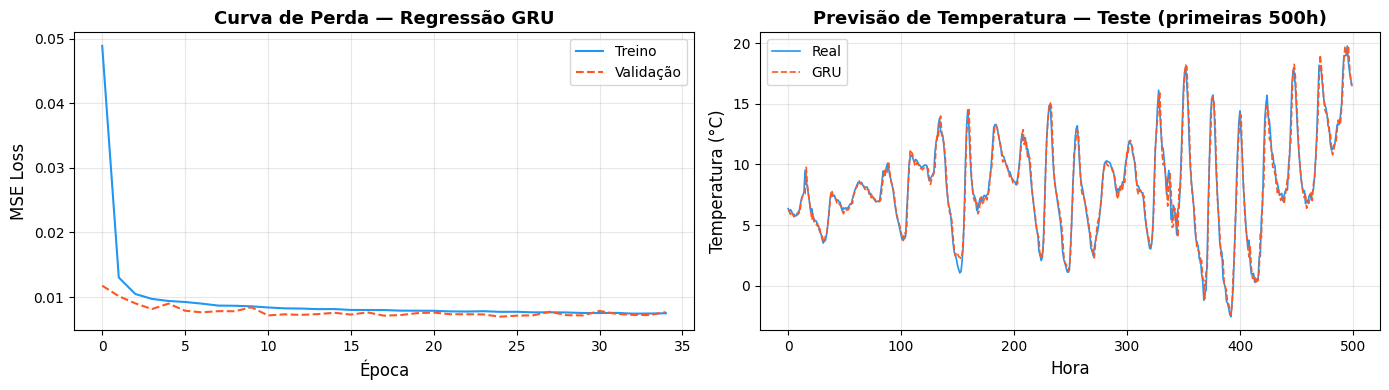

In [7]:
modelo_reg.eval()
with torch.no_grad():
    pred_norm_va = modelo_reg(X_va_t).cpu().numpy().flatten()
    pred_norm_te = modelo_reg(X_te_t).cpu().numpy().flatten()

def desnorm(arr):
    return scaler_y.inverse_transform(arr.reshape(-1, 1)).flatten()

pred_va, real_va = desnorm(pred_norm_va), desnorm(y_va)
pred_te, real_te = desnorm(pred_norm_te), desnorm(y_te)

def metricas(real, pred, label=""):
    rmse = np.sqrt(np.mean((real - pred) ** 2))
    mae  = np.mean(np.abs(real - pred))
    r2   = 1 - np.sum((real - pred)**2) / np.sum((real - real.mean())**2)
    print(f"{label}  RMSE={rmse:.4f}°C  MAE={mae:.4f}°C  R²={r2:.4f}")
    return rmse, mae, r2

rmse_va, mae_va, r2_va = metricas(real_va, pred_va, "Validação")
rmse_te, mae_te, r2_te = metricas(real_te, pred_te, "Teste     ")

# ── Curvas de treinamento ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist_tr, label="Treino",    color="#2196F3", lw=1.5)
ax.plot(hist_va, label="Validação", color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("MSE Loss", fontsize=12)
ax.set_title("Curva de Perda — Regressão GRU", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# ── Predições vs Real ────────────────────────────────────────────────────────
ax = axes[1]
n_plot = 500
ax.plot(real_te[:n_plot], label="Real",   color="#2196F3", lw=1.2)
ax.plot(pred_te[:n_plot], label="GRU",    color="#FF5722", lw=1.2, linestyle="--")
ax.set_xlabel("Hora", fontsize=12)
ax.set_ylabel("Temperatura (°C)", fontsize=12)
ax.set_title(f"Previsão de Temperatura — Teste (primeiras {n_plot}h)", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ── 4.6 Salvar o modelo treinado ─────────────────────────────────────────────
import os
os.makedirs("models", exist_ok=True)

checkpoint_reg = {
    "model_state_dict": modelo_reg.state_dict(),
    "scaler_X":         scaler_X,
    "scaler_y":         scaler_y,
    "seq_len":          SEQ_LEN,
    "features":         FEATURES,
    "target":           TARGET,
    "metricas_teste":   {"rmse": rmse_te, "mae": mae_te, "r2": r2_te},
}
torch.save(checkpoint_reg, "models/gru_temperatura.pth")
print("Checkpoint salvo em models/gru_temperatura.pth")

Checkpoint salvo em models/gru_temperatura.pth


---

## 5. Caso 2 — Reconhecimento de Atividade Humana (Classificação)

### 5.1 Objetivo

Dado um trecho de 2,56 segundos de sinais de acelerômetro e giroscópio capturados por um smartphone, classificar a **atividade** que o usuário está realizando — **idêntico ao Caso 2 da Aula 05**, para comparação direta GRU × LSTM.

### 5.2 Dataset: UCI HAR (Human Activity Recognition)

**Fonte:** [UCI Machine Learning Repository — Human Activity Recognition](https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones)

| Classe | Atividade |
|--------|-----------|
| 0 | WALKING |
| 1 | WALKING UPSTAIRS |
| 2 | WALKING DOWNSTAIRS |
| 3 | SITTING |
| 4 | STANDING |
| 5 | LAYING |

- **128 timesteps** × **9 canais** (acelerômetro + giroscópio corpo + acelerômetro total)
- **7 352** amostras de treino / **2 947** de teste

Treino : (7352, 128, 9)  | Teste: (2947, 128, 9)


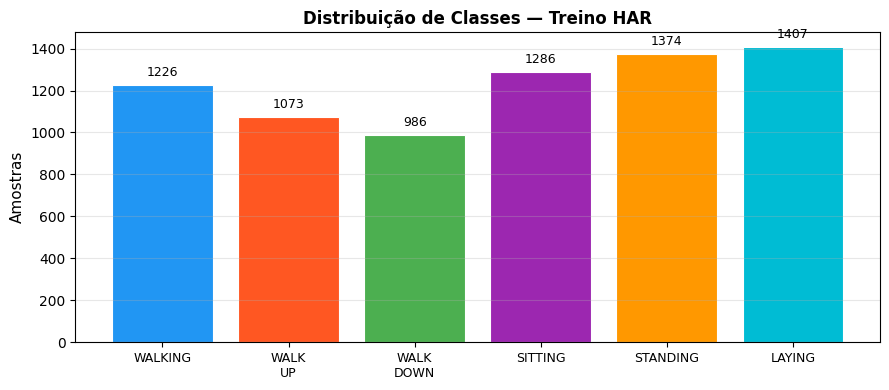

In [9]:
HAR_ROOT = "data/har/UCI HAR Dataset"

CANAIS = [
    "body_acc_x",  "body_acc_y",  "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

NOMES_CLF = ["WALKING", "WALK\nUP", "WALK\nDOWN", "SITTING", "STANDING", "LAYING"]

def carregar_har(split):
    sinais = []
    for canal in CANAIS:
        arq = f"{HAR_ROOT}/{split}/Inertial Signals/{canal}_{split}.txt"
        sinais.append(np.loadtxt(arq))
    X = np.stack(sinais, axis=-1).astype(np.float32)   # (N, 128, 9)
    y = np.loadtxt(f"{HAR_ROOT}/{split}/y_{split}.txt", dtype=int) - 1
    return X, y

X_tr_raw, y_tr_c = carregar_har("train")
X_te_raw, y_te_c = carregar_har("test")
print(f"Treino : {X_tr_raw.shape}  | Teste: {X_te_raw.shape}")

# Distribuição de classes
contagem = np.bincount(y_tr_c)
fig, ax = plt.subplots(figsize=(9, 4))
cores = ["#2196F3","#FF5722","#4CAF50","#9C27B0","#FF9800","#00BCD4"]
bars = ax.bar(range(6), contagem, color=cores, edgecolor="white", linewidth=0.8)
ax.set_xticks(range(6)); ax.set_xticklabels(NOMES_CLF, fontsize=9)
ax.set_ylabel("Amostras", fontsize=11)
ax.set_title("Distribuição de Classes — Treino HAR", fontsize=12, fontweight="bold")
for bar, n in zip(bars, contagem):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(n),
            ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()

### 5.3 Preparação dos Dados

Normalização por canal (fit apenas no treino), igual à Aula 05.

| Conjunto | Amostras | Fonte |
|----------|----------|-------|
| Treino   | 7 352    | `train/` |
| Teste    | 2 947    | `test/`  |

In [10]:
N_tr, T, C = X_tr_raw.shape
scaler_clf = StandardScaler()
X_tr_norm = scaler_clf.fit_transform(X_tr_raw.reshape(-1, C)).reshape(N_tr, T, C)
X_te_norm = scaler_clf.transform(X_te_raw.reshape(-1, C)).reshape(-1, T, C)

X_tr_ct = torch.tensor(X_tr_norm, dtype=torch.float32).to(device)
y_tr_ct = torch.tensor(y_tr_c,    dtype=torch.long).to(device)
X_te_ct = torch.tensor(X_te_norm, dtype=torch.float32).to(device)
y_te_c  = torch.tensor(y_te_c,    dtype=torch.long)

loader_tr_c = DataLoader(TensorDataset(X_tr_ct, y_tr_ct), batch_size=128, shuffle=True)
print("Dados prontos para treinamento.")

Dados prontos para treinamento.


### 5.4 Modelo GRU para Classificação

```
Entrada  : (batch, 128, 9)   ← 128 timesteps, 9 canais
GRU      : hidden=128, layers=2, dropout=0.3
Saída h_T: (batch, 128)      ← último estado oculto
Dropout  : 0.3
FC       : Linear(128 → 6)
Loss     : CrossEntropyLoss
```

In [11]:
class ClassificacaoGRU(nn.Module):
    """GRU many-to-one para classificação de atividade humana."""

    def __init__(self, input_size=9, hidden_size=128, num_layers=2,
                 n_classes=6, dropout=0.3):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(self.drop(h_n[-1]))

modelo_clf = ClassificacaoGRU().to(device)
total_clf  = sum(p.numel() for p in modelo_clf.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {total_clf:,}")
print(modelo_clf)

Parâmetros treináveis: 153,222
ClassificacaoGRU(
  (gru): GRU(9, 128, num_layers=2, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


### 5.5 Treinamento

| Hiperparâmetro | Valor |
|----------------|-------|
| Épocas         | 30    |
| Learning rate  | 1e-3  |
| Batch size     | 128   |
| Otimizador     | Adam  |
| Perda          | CrossEntropyLoss |
| Clip gradiente | 1.0   |

In [12]:
EPOCHS_CLF = 30
LR_CLF     = 1e-3

criterio_clf   = nn.CrossEntropyLoss()
otimizador_clf = optim.Adam(modelo_clf.parameters(), lr=LR_CLF)

hist_loss_tr_c, hist_loss_te_c = [], []
hist_acc_tr_c,  hist_acc_te_c  = [], []

for epoca in range(1, EPOCHS_CLF + 1):
    modelo_clf.train()
    loss_soma, acertos, total = 0.0, 0, 0
    for xb, yb in loader_tr_c:
        logits = modelo_clf(xb)
        loss   = criterio_clf(logits, yb)
        otimizador_clf.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(modelo_clf.parameters(), 1.0)
        otimizador_clf.step()
        loss_soma += loss.item()
        acertos   += (logits.argmax(1) == yb).sum().item()
        total     += len(yb)

    modelo_clf.eval()
    with torch.no_grad():
        logits_te = modelo_clf(X_te_ct)
        loss_te   = criterio_clf(logits_te, y_te_c.to(device)).item()
        acc_te    = (logits_te.argmax(1).cpu() == y_te_c).float().mean().item()

    hist_loss_tr_c.append(loss_soma / len(loader_tr_c))
    hist_loss_te_c.append(loss_te)
    hist_acc_tr_c.append(acertos / total)
    hist_acc_te_c.append(acc_te)

    if epoca % 5 == 0:
        print(f"Época {epoca:3d} | Loss: {hist_loss_tr_c[-1]:.4f} / {loss_te:.4f} "
              f"| Acc: {acertos/total:.4f} / {acc_te:.4f}")

Época   5 | Loss: 0.1349 / 0.3865 | Acc: 0.9475 / 0.8935
Época  10 | Loss: 0.1172 / 0.3366 | Acc: 0.9525 / 0.9121
Época  15 | Loss: 0.1182 / 0.4272 | Acc: 0.9510 / 0.8904
Época  20 | Loss: 0.1058 / 0.4014 | Acc: 0.9577 / 0.9097
Época  25 | Loss: 0.0987 / 0.3204 | Acc: 0.9581 / 0.9125
Época  30 | Loss: 0.1124 / 0.3307 | Acc: 0.9576 / 0.9213


### 5.6 Resultados

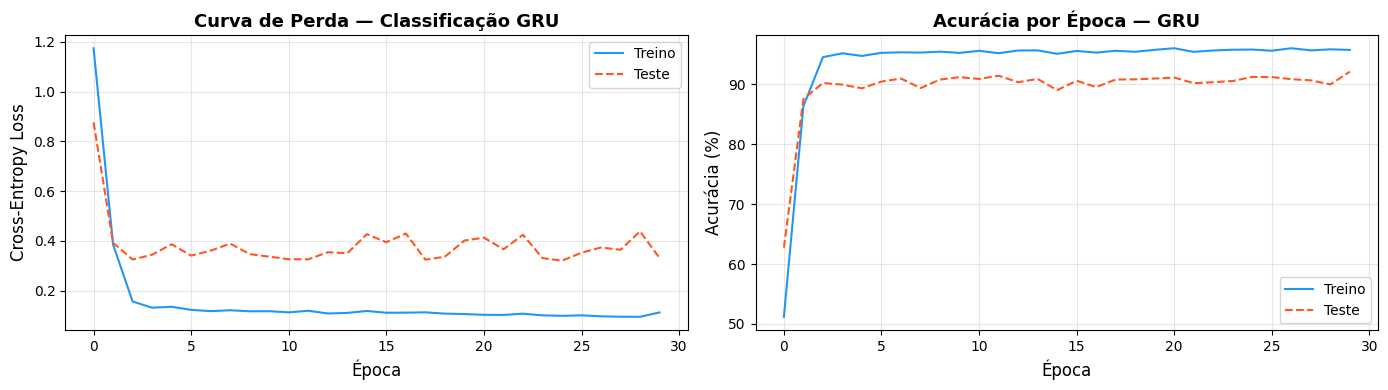

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist_loss_tr_c, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_loss_te_c, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12); ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Curva de Perda — Classificação GRU", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([a*100 for a in hist_acc_tr_c], label="Treino", color="#2196F3", lw=1.5)
ax.plot([a*100 for a in hist_acc_te_c], label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12); ax.set_ylabel("Acurácia (%)", fontsize=12)
ax.set_title("Acurácia por Época — GRU", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

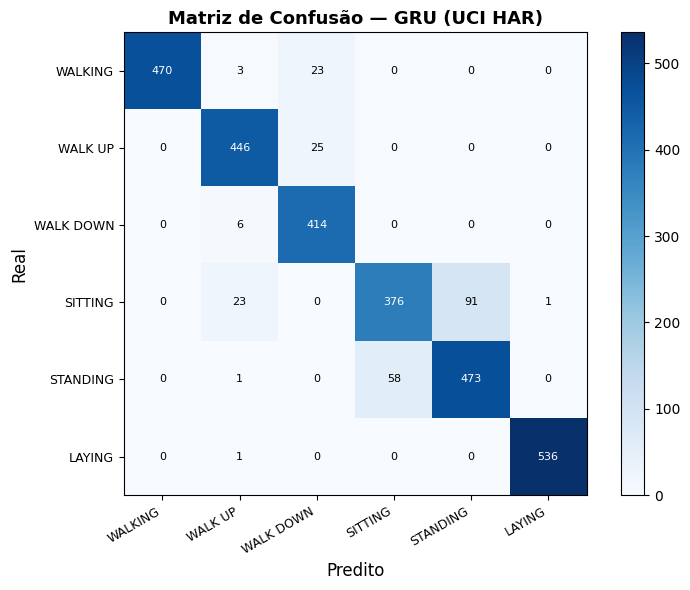


Acurácia no teste: 0.9213 (92.13%)


In [14]:
# Matriz de confusão
modelo_clf.eval()
with torch.no_grad():
    pred_te = modelo_clf(X_te_ct).argmax(1).cpu().numpy()

labels_curtos = ["WALKING", "WALK UP", "WALK DOWN", "SITTING", "STANDING", "LAYING"]

matriz = np.zeros((6, 6), dtype=int)
for real, pred in zip(y_te_c.numpy(), pred_te):
    matriz[real, pred] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz, cmap="Blues")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(6)); ax.set_xticklabels(labels_curtos, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(6)); ax.set_yticklabels(labels_curtos, fontsize=9)
ax.set_xlabel("Predito", fontsize=12); ax.set_ylabel("Real", fontsize=12)
ax.set_title("Matriz de Confusão — GRU (UCI HAR)", fontsize=13, fontweight="bold")
for i in range(6):
    for j in range(6):
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center", fontsize=8,
                color="white" if matriz[i, j] > matriz.max() * 0.6 else "black")
plt.tight_layout()
plt.show()

acc_final = pred_te[pred_te == y_te_c.numpy()].shape[0] / len(y_te_c)
print(f"\nAcurácia no teste: {acc_final:.4f} ({acc_final*100:.2f}%)")

In [15]:
# ── 5.7 Salvar o modelo treinado ─────────────────────────────────────────────
NOMES_ATIVIDADES = ["WALKING", "WALKING UPSTAIRS", "WALKING DOWNSTAIRS",
                    "SITTING", "STANDING", "LAYING"]

checkpoint_clf = {
    "model_state_dict": modelo_clf.state_dict(),
    "scaler_clf":       scaler_clf,
    "activity_labels":  NOMES_ATIVIDADES,
    "input_size":       9,
    "hidden_size":      128,
    "num_layers":       2,
    "n_classes":        6,
}
torch.save(checkpoint_clf, "models/gru_har.pth")
print("Checkpoint salvo em models/gru_har.pth")

Checkpoint salvo em models/gru_har.pth


---

## 6. Comparativo e Próximos Passos

### 6.1 LSTM × GRU — Síntese

| Aspecto | LSTM (Aula 05) | GRU (Aula 06) |
|---------|---------------|---------------|
| **Gates** | 3 (forget, input, output) | 2 (reset, update) |
| **Vetores de estado** | $h_t$ e $c_t$ | Apenas $h_t$ |
| **Parâmetros (hidden=64, in=8)** | ~50 k | ~37 k |
| **Convergência** | Mais lenta | Mais rápida |
| **Datasets pequenos** | Risco de overfitting maior | Generaliza bem |
| **Sequências longas** | Vantagem potencial | Competitivo |
| **PyTorch** | `nn.LSTM` → `(out, (h_n, c_n))` | `nn.GRU` → `(out, h_n)` |

### 6.2 Quando usar cada um?

| Cenário | Escolha |
|---------|---------|
| Dataset pequeno (< 10k amostras) | **GRU** |
| Restrição de memória ou tempo de treino | **GRU** |
| Sequências > 500 passos com dependências complexas | **LSTM** |
| Incerto — baseline rápido | **GRU**, depois compare com LSTM |

### 6.3 Próximos Passos

A aula seguinte aborda **Redes Neurais Convolucionais (CNN)** — arquitetura projetada para dados com estrutura espacial (imagens). Enquanto RNN e GRU processam **sequências no tempo**, CNNs processam **padrões no espaço**.